<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/CNN_for_CIFAR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, GlobalMaxPooling2D
from tensorflow.keras.models import Model

In [13]:
cifar10 = tf.keras.datasets.cifar10 # O nome do dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten() # Aplicando o flatten
print("x_train.shape:", x_train.shape)
print("y_train.shape:", y_train.shape)

x_train.shape: (50000, 32, 32, 3)
y_train.shape: (50000,)


In [14]:
K = len(set(y_train)) # Número de classes
print("number of classes:", K)

number of classes: 10


In [16]:
i = Input(shape=x_train[0].shape)
x = Conv2D(32, (3, 3), strides=2, activation='relu')(i) # um filtro reduzir
x = Conv2D(64, (3, 3), strides=2, activation='relu')(x)
x = Conv2D(128, (3, 3), strides=2, activation='relu')(x) # aumento de filtros
x = Flatten()(x) # camada de planarização

x = Dropout(0.5)(x) # dropout para evitar overfitting
x = Dense(1024, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x) # função softmax
model = Model(i, x) # criando o modelo

In [17]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

r = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 51ms/step - accuracy: 0.4182 - loss: 1.5884 - val_accuracy: 0.5252 - val_loss: 1.2828
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 34ms/step - accuracy: 0.5381 - loss: 1.2889 - val_accuracy: 0.5756 - val_loss: 1.1677
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 86s 37ms/step - accuracy: 0.5844 - loss: 1.1629 - val_accuracy: 0.6292 - val_loss: 1.0521
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.6182 - loss: 1.0718 - val_accuracy: 0.6372 - val_loss: 1.0183
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 82s 36ms/step - accuracy: 0.6456 - loss: 0.9924 - val_accuracy: 0.6731 - val_loss: 0.9348
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 56s 36ms/step - accuracy: 0.6644 - loss: 0.9398 - val_accuracy: 0.6848 - val_loss: 0.9002
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 84s 37ms/step - accuracy: 0.6852 - loss: 0.8897 - val_accuracy: 0.6962 - val_loss: 0.8792
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 55s 35ms/step - accuracy: 0.6974 -

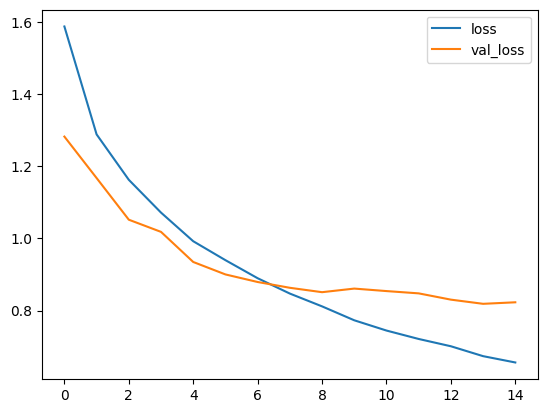

In [18]:
# taxas de erro por interação
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

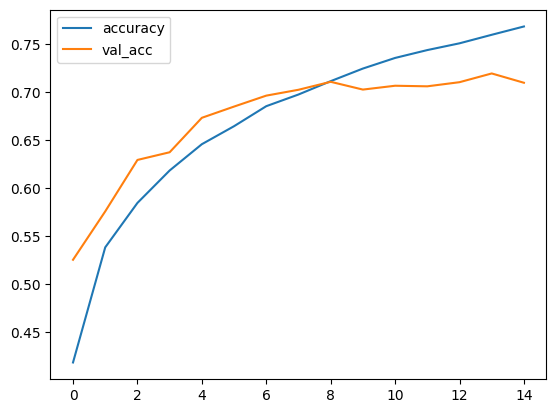

In [19]:
# taxas de erro e acurácia
plt.plot(r.history['accuracy'], label='accuracy')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Confusion matrix, without normalization
[[749  30  34  24  15   6  13  14  80  35]
 [ 12 846   7   9   2   5  13   2  27  77]
 [ 63   6 551 117  89  59  67  18  16  14]
 [ 15   7  59 572  54 176  66  19  17  15]
 [ 19   3  56  97 660  38  69  45  10   3]
 [ 10   5  44 237  49 575  32  35   8   5]
 [  6   5  32  69  39  33 801   5   8   2]
 [ 10   0  27  68  84  64  12 708   7  20]
 [ 47  33  11  20   8   6   8   2 834  31]
 [ 24  98   5  19   2  10   8  13  21 800]]


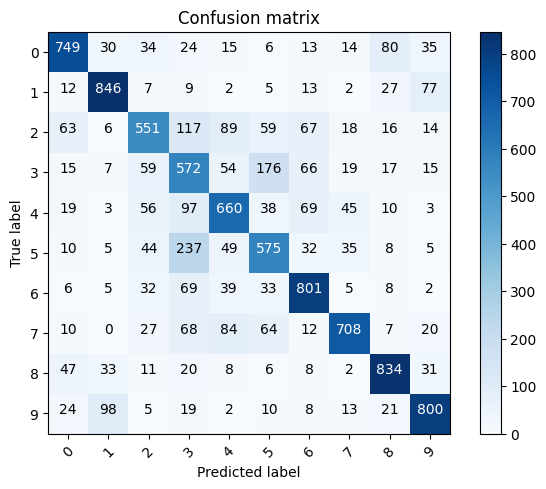

In [20]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix
import itertools

def plot_confusion_matrix(cm,
                          classes, # Classes
                          normalize=False, # Normalização
                          title='Confusion matrix',
                          cmap=plt.cm.Blues # Cor
                          ):
    # normalização da matriz
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print("Confusion matrix, without normalization")
    print(cm)

    # plotagem da matriz
    plt.imshow(cm, interpolation='nearest', cmap=cmap) # imagem da matriz
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes)) # Marcas
    plt.xticks(tick_marks, classes, rotation=45) # rotulos do eixo x
    plt.yticks(tick_marks, classes) # rotulos do eixo y

    # formatação dos números
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2. # limiar para a cor do texto
    # adicionando texto na matriz
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                horizontalalignment='center',
                color='white' if cm[i, j] > thresh else 'black')

    # adicionando rotulos
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.show()

# fazendo a predição
p_test = model.predict(x_test).argmax(axis=1)
# gerando a matriz de confusão
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, list(range(10)))